# Задание 1. Создайте и обучите U-Net-подобную сеть для сегментации документов. 

В качастве датасета используется фрагмент [midv500](https://arxiv.org/abs/1807.05786) это датсет содержащий фотографии документов таких как паспорт или водительское удостоверение.

Подзадачи:
- Загрузить данные
- Описать модель
- Выбрать Loss функцию
- Убедиться что модель обучается


Результаты (masks_in_progress) могут выглядеть так: 

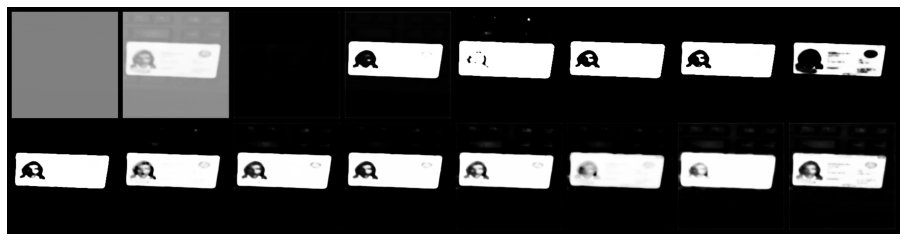


## 1.1 Загрузка данныx







In [1]:
import glob
from PIL import Image
from torch.utils.data import Dataset
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader
import torchvision

In [2]:
! wget http://fmb.images.gan4x4.ru/hse/midv500p.zip
! unzip -q midv500p.zip
! rm midv500p.zip

--2022-06-11 17:42:35--  http://fmb.images.gan4x4.ru/hse/midv500p.zip
Resolving fmb.images.gan4x4.ru (fmb.images.gan4x4.ru)... 212.24.105.216
Connecting to fmb.images.gan4x4.ru (fmb.images.gan4x4.ru)|212.24.105.216|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9183651 (8.8M) [application/zip]
Saving to: ‘midv500p.zip’

midv500p.zip        100%[===================>]   8.76M  2.63MB/s    in 3.3s    

2022-06-11 17:42:38 (2.63 MB/s) - ‘midv500p.zip’ saved [9183651/9183651]



## 1.2 Dataloader.

MaskDataset возвращает часть датасета для обучения при train_part == True, и тестовую часть при False.

Каждый экземпляр датасета состоит из двух изображений: входного изображения и размеченной маски.

In [3]:
class MaskDataset(Dataset):
  def __init__(self, train_part = True, transform = None):
    path = 'midv500p/train' if train_part else 'midv500p/val'
    self.files = glob.glob(path+"/image/*")
    self.masks = [fn.replace('image', 'mask').replace('jpg', 'png') for fn in self.files]

    self.transform = transform
    self.loaded_images = [transforms.ToTensor()(Image.open(filename)) for filename in self.files]
    self.loaded_masks = [transforms.ToTensor()(Image.open(filename)) for filename in self.masks]

  def __getitem__(self, i):
    img = self.loaded_images[i]
    mask = self.loaded_masks[i]
    if self.transform is not None:
        concat = torch.cat((img, mask))
        concat_transformed = self.transform(concat)
        img, mask = torch.split(concat_transformed, 3)
    return img, mask

  def __len__(self):
    return len(self.files)

Подумайте какие аугментации/нормализации приемлимы и примените их. (В baseline-классе применяется одинаковая аугментация для изображения и для маски)

P.S. Допускается использовать библиотеку [albumentation](https://github.com/albumentations-team/albumentations)

In [4]:
from torchvision import transforms
from torch.utils.data import DataLoader
import albumentations as A

transform_train  = transforms.Compose([
                                        transforms.GaussianBlur(kernel_size=(5, 5), sigma=(0.02, 0.2)),
                                        transforms.RandomVerticalFlip(p=0.5),
                                        transforms.RandomHorizontalFlip(p = 0.5),
                                        transforms.Resize((224,224))
                                        ])
transform_val = transforms.Compose([
                                        # transforms.GaussianBlur(kernel_size=(5, 5), sigma=(0.02, 0.2)),
                                        # transforms.RandomVerticalFlip(p=0.5),
                                        # transforms.RandomHorizontalFlip(p = 0.5),
                                        transforms.Resize((224,224))
                                    ])

trainset = MaskDataset(train_part = True, transform =  transform_train)
valset = MaskDataset(train_part = False, transform =  transform_val)

train_loader = DataLoader(trainset, batch_size = 64, shuffle =True)
val_loader = DataLoader(valset, batch_size = 4, shuffle =False)

print(len(trainset))
print(len(valset))

553
62


Убедитесь что код работает, для этого воспользуйтесь приведенным ниже тестом. 

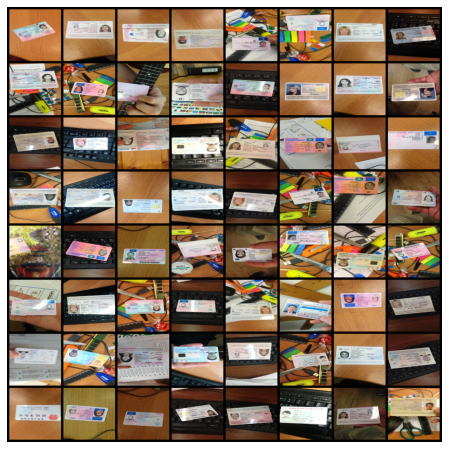

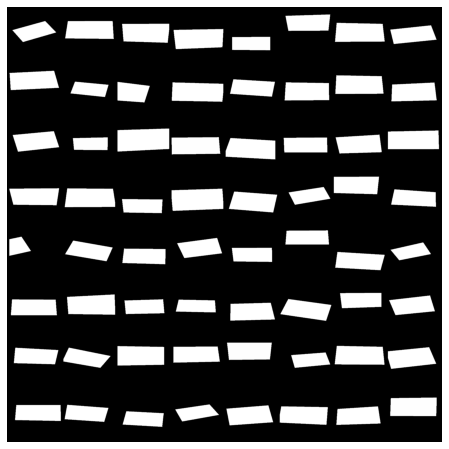

In [5]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (16,8)

def show(batch):
    img_grid = make_grid(batch, padding=10)
    plt.figure()
    plt.axis('off')
    plt.imshow(np.transpose(img_grid.numpy(), (1,2,0)))

images, masks = iter(train_loader).next()

show(images)
show(masks)

In [6]:
images.shape

torch.Size([64, 3, 224, 224])

## 1.3 Опишите структуру  модели

Рекомендуется использовать [UNet](https://arxiv.org/pdf/1505.04597.pdf) - подобную архитектуру.

Однако вы можете ограничиться 2-3 -мя сжимающими и таким  же количеством разжимающих слоев.


In [14]:
from torch.nn import *

class MiniUnet(Module):

    def __init__(self, channels=[32,64]):
        super(MiniUnet, self).__init__()
        neuron = 3
        self.pool = MaxPool2d((2, 2))
        self.conv = Conv2d(neuron, 1, (1,1), padding="same")
        self.conv1 = Conv2d(neuron * 1, neuron * 1, (3, 3), padding="same")
        self.conv2 = Conv2d(neuron * 1, neuron * 2, (3, 3), padding="same")
        self.convm = Conv2d(neuron * 2, neuron * 2, (3, 3), padding="same")
        self.deconv2 = ConvTranspose2d(neuron * 2, neuron * 2, (3, 3), stride=(2, 2), padding=1, output_padding = 1)
        self.uconv2 = Conv2d(neuron * 4, neuron * 2, (3, 3), padding="same")
        self.deconv1 = ConvTranspose2d(neuron * 2, neuron * 1, (3, 3), stride=(2, 2), padding=1, output_padding = 1)
        self.uconv1 = Conv2d(neuron * 2, neuron * 1, (3, 3), padding="same")
        self.relu = ReLU()
        self.sigmoid = Sigmoid()

    def forward(self, x):
        conv1 = self.relu(self.conv1(x))
        pool = self.pool(conv1)
        conv2 = self.relu(self.conv2(pool))
        pool = self.pool(conv2)
        convm = self.relu(self.convm(pool))
        convm = self.relu(self.convm(convm))
        convm = self.relu(self.convm(convm))
        deconv2 = self.relu(self.deconv2(convm))
        uconv2 = torch.cat([deconv2, conv2], dim = 1)
        uconv2 = self.relu(self.uconv2(uconv2))
        deconv1 = self.deconv1(uconv2)
        uconv1 = torch.cat([deconv1, conv1], dim = 1)
        uconv1 = self.relu(self.uconv1(uconv1))
        x = self.sigmoid(self.conv(uconv1))

        return x 

## 1.4 Обучение

### 1.4.1 Выберите loss - функцию

Для этого вам потредуется выбрать Loss-функцию, например BinaryDiceLoss (см. материал лекции)


In [8]:
class BinaryDiceLoss(nn.Module):
    """Soft Dice loss of binary class
    Args:
        p: Denominator value: \sum{x^p} + \sum{y^p}, default: 2
        predict: A tensor of shape [N, *]
        target: A tensor of shape same with predict
       Returns:
        Loss tensor

    """

    def __init__(self, p=2, epsilon=1e-6):
        super().__init__()
        self.p = p  # pow degree
        self.epsilon = epsilon

    def forward(self, predict, target):
        predict = predict.flatten(1)
        target = target.flatten(1)

        # https://pytorch.org/docs/stable/generated/torch.mul.html
        num = torch.sum(torch.mul(predict, target), dim=1) + self.epsilon
        den = torch.sum(predict.pow(self.p) + target.pow(self.p), dim=1) + self.epsilon
        loss = 1 - 2 * num / den

        return loss.mean()  # over batch


criterion = BinaryDiceLoss()
output = torch.tensor([[[1, 1, 1], [1, 1, 1], [1, 1, 1]]], dtype=torch.float)

target = torch.tensor([[[1, 1, 1], [1, 1, 1], [1, 1, 1]]], dtype=torch.float)

soft_loss = criterion(output.unsqueeze(0), target.unsqueeze(0))

### 1.4.2 Обучите модель

In [9]:
def train(model, criterion, optimizer, epoch=None, masks_in_progress=[]):
    ep_loss = 0
    model.train()
    for img_batch, masks_batch in train_loader:
        optimizer.zero_grad()
        output = model(img_batch.to(device))
        loss = criterion(output, masks_batch.to(device))
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()

    val_loss = 0
    for i, batch in enumerate(val_loader):
        with torch.no_grad():
            img_batch, masks_batch = batch
            output = model(img_batch.to(device))
            loss = criterion(output, masks_batch.to(device))
            val_loss += loss.item()
            if i == 0:
                masks_in_progress.append(output[0].cpu())

    print("Epoch {} Train loss {:.2f} Val loss {:.2f}".format(epoch, ep_loss/len(train_loader), val_loss/len(val_loader)))

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [15]:
model = MiniUnet(32).to(device)
criterion = BinaryDiceLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
with torch.no_grad():
    masks_in_progress = [model(next(iter(val_loader))[0].to(device))[0].cpu()] # Add mask before train

In [16]:
for epoch in range(20):
    train(model, criterion, optimizer, epoch, masks_in_progress)

Epoch 0 Train loss 0.48 Val loss 0.46
Epoch 1 Train loss 0.42 Val loss 0.37
Epoch 2 Train loss 0.28 Val loss 0.21
Epoch 3 Train loss 0.18 Val loss 0.19
Epoch 4 Train loss 0.18 Val loss 0.19
Epoch 5 Train loss 0.18 Val loss 0.19
Epoch 6 Train loss 0.17 Val loss 0.19
Epoch 7 Train loss 0.18 Val loss 0.19
Epoch 8 Train loss 0.17 Val loss 0.19
Epoch 9 Train loss 0.17 Val loss 0.19
Epoch 10 Train loss 0.17 Val loss 0.19
Epoch 11 Train loss 0.17 Val loss 0.19
Epoch 12 Train loss 0.17 Val loss 0.19
Epoch 13 Train loss 0.17 Val loss 0.19
Epoch 14 Train loss 0.17 Val loss 0.20
Epoch 15 Train loss 0.17 Val loss 0.19
Epoch 16 Train loss 0.17 Val loss 0.19
Epoch 17 Train loss 0.17 Val loss 0.19
Epoch 18 Train loss 0.17 Val loss 0.19
Epoch 19 Train loss 0.17 Val loss 0.19


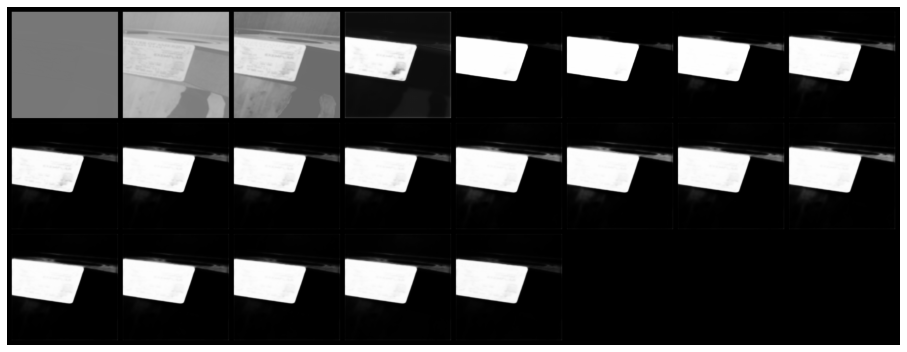

In [17]:
show(masks_in_progress)

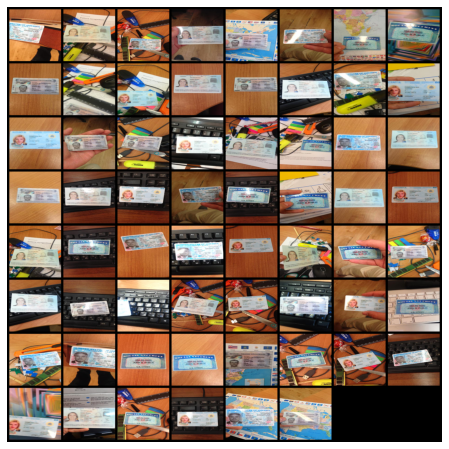

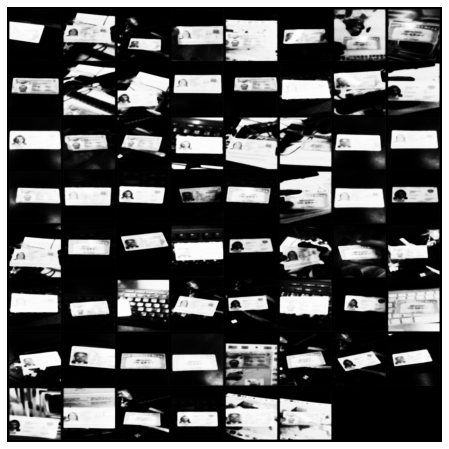

In [18]:
def show_valset_pred(model):
    images, pred_masks = [], []
    for batch in valset:
        with torch.no_grad():
            img, mask = batch
            images.append(img.unsqueeze(0))
            output = model(img.unsqueeze(0).to(device))
            pred_masks.append(output.cpu())
    show(torch.stack(images).squeeze())
    show(torch.stack(pred_masks).squeeze(1))
show_valset_pred(model)

# Задание 2. Попробовать другую лосс-функцию.


In [19]:
criterion =  nn.BCELoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
with torch.no_grad():
    masks_in_progress = [model(next(iter(val_loader))[0].to(device))[0].cpu()] # Add mask before train

In [20]:
for epoch in range(20):
    train(model, criterion, optimizer, epoch, masks_in_progress)

Epoch 0 Train loss 0.32 Val loss 0.30
Epoch 1 Train loss 0.27 Val loss 0.29
Epoch 2 Train loss 0.27 Val loss 0.29
Epoch 3 Train loss 0.27 Val loss 0.29
Epoch 4 Train loss 0.27 Val loss 0.29
Epoch 5 Train loss 0.27 Val loss 0.29
Epoch 6 Train loss 0.27 Val loss 0.29
Epoch 7 Train loss 0.27 Val loss 0.29
Epoch 8 Train loss 0.27 Val loss 0.30
Epoch 9 Train loss 0.27 Val loss 0.29
Epoch 10 Train loss 0.27 Val loss 0.28
Epoch 11 Train loss 0.27 Val loss 0.29
Epoch 12 Train loss 0.26 Val loss 0.28
Epoch 13 Train loss 0.28 Val loss 0.28
Epoch 14 Train loss 0.27 Val loss 0.29
Epoch 15 Train loss 0.26 Val loss 0.28
Epoch 16 Train loss 0.26 Val loss 0.28
Epoch 17 Train loss 0.25 Val loss 0.28
Epoch 18 Train loss 0.25 Val loss 0.27
Epoch 19 Train loss 0.25 Val loss 0.27


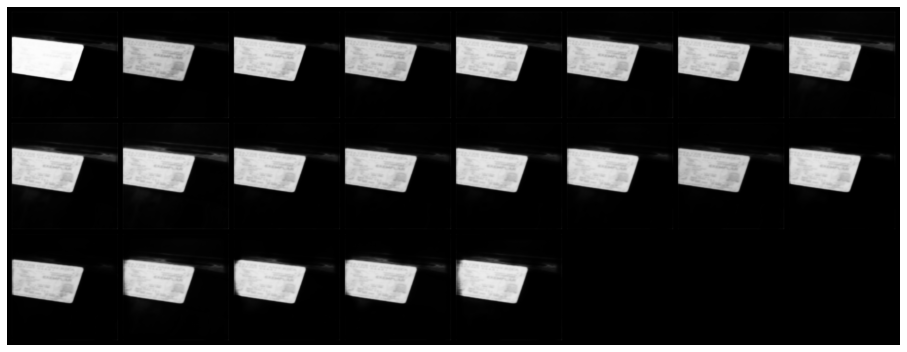

In [21]:
show(masks_in_progress)

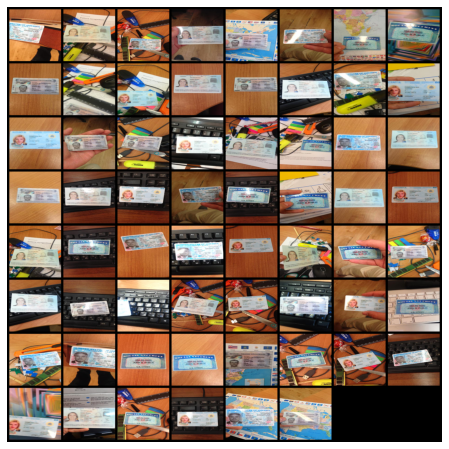

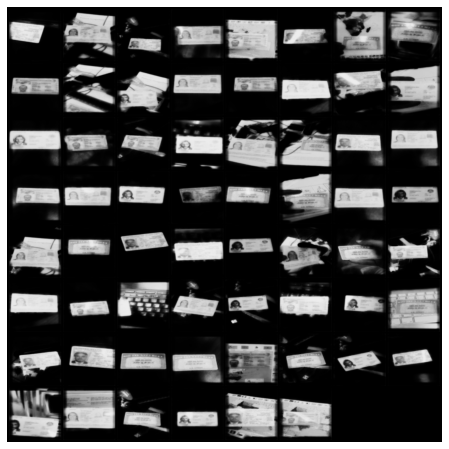

In [22]:
def show_valset_pred(model):
    images, pred_masks = [], []
    for batch in valset:
        with torch.no_grad():
            img, mask = batch
            images.append(img.unsqueeze(0))
            output = model(img.unsqueeze(0).to(device))
            pred_masks.append(output.cpu())
    show(torch.stack(images).squeeze())
    show(torch.stack(pred_masks).squeeze(1))
show_valset_pred(model)

В общем нормально обучилось все.

# (Дополнительно) Сложно, долго, но интересно!

Делаем свой сканер документов по фотографии. Цель хорошо описывается картинками:

<center>
<img src ="https://raw.githubusercontent.com/Annndruha/scanner_by_photo/master/cutter/docs/example_in.PNG" width="300">
<img src ="https://upload.wikimedia.org/wikipedia/commons/thumb/7/71/Arrow_east.svg/320px-Arrow_east.svg.png" width="100">
<img src ="https://raw.githubusercontent.com/Annndruha/scanner_by_photo/master/cutter/docs_out/example_out.jpg" width="150"></center>

Если решились выполнять задание, то для удобства сохраните модель из предыдущего задания, а лучше некоторый набор предсказанных изображений: исходное, оригинальная маска, предсказанная маска. (весь validation датасет, например).

## Подзадача 1.
Используя маски, которые выдаёт модель, любыми алгоритмами найдите на масках углы документа (или границы документа).

Большинство известных алгоритмов можно найти в opencv, например:
* https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
* https://docs.opencv.org/4.6.0/dd/d49/tutorial_py_contour_features.html
* https://docs.opencv.org/4.x/dc/d0d/tutorial_py_features_harris.html

Рекомендуется перед применением алгоритмов [маску бинаризовать](https://docs.opencv.org/3.4/db/d8e/tutorial_threshold.html) по порогу: все пиксели выше порога сделать истинно белыми, а ниже - чёрными. (И проверить качество бинаризованных изображений)

In [ ]:
# CODE

## Подзадача 2.

Произвести трансформацию перспективы по найденным углам/контурам. Разумеется, трансформацию необходимо производить над исходным изображением, а не над масками.


Для этого используются функции `cv2.getPerspectiveTransform` и
`cv2.warpPerspective`.

In [ ]:
# CODE